# Proyecto Integrado de Ciencia de Datos
## Análisis de Netflix User Behavior Dataset

### Integrantes:
- Nombre : Johann Carrasco
- Nombre : Pablo Daza
- Nombre : Ricardo Ruiz

### Asignatura:
Programación para la Ciencia de Datos (SCY1101)

## 1. Introducción

En este proyecto se trabaja con un dataset de comportamiento de usuarios de Netflix.
El objetivo es limpiar, transformar y preparar los datos para obtener un conjunto de datos más útil

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [19]:
df = pd.read_csv("netflix_user_behavior_dataset.csv")
print("Dataset cargado correctamente")
df.head()


Dataset cargado correctamente


,user_id,age,gender,country,account_age_months,subscription_type,monthly_fee,payment_method,primary_device,devices_used,favorite_genre,avg_watch_time_minutes,watch_sessions_per_week,binge_watch_sessions,completion_rate,rating_given,content_interactions,recommendation_click_rate,days_since_last_login,churned
0,U100000,56,Male,India,17,Standard,15.99,PayPal,Laptop,1,Sci-Fi,220,17,3,60,1.7,5,66,16,No
1,U100001,46,Female,USA,20,Standard,12.99,PayPal,Tablet,2,Documentary,76,15,4,71,4.6,7,78,14,No
2,U100002,32,Other,USA,25,Basic,15.99,PayPal,Tablet,2,Comedy,215,6,13,33,2.0,27,29,41,No
3,U100003,60,Male,Canada,37,Standard,12.99,PayPal,Smart TV,3,Action,280,4,9,58,1.2,9,23,22,No
4,U100004,25,Male,Brazil,23,Premium,12.99,PayPal,Mobile,3,Horror,261,15,9,64,1.3,49,56,54,No


In [20]:
# Dimensiones del dataset
df.shape

(50000, 20)

In [21]:
# Información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   user_id                    50000 non-null  object 
 1   age                        50000 non-null  int64  
 2   gender                     50000 non-null  object 
 3   country                    50000 non-null  object 
 4   account_age_months         50000 non-null  int64  
 5   subscription_type          50000 non-null  object 
 6   monthly_fee                50000 non-null  float64
 7   payment_method             50000 non-null  object 
 8   primary_device             50000 non-null  object 
 9   devices_used               50000 non-null  int64  
 10  favorite_genre             50000 non-null  object 
 11  avg_watch_time_minutes     50000 non-null  int64  
 12  watch_sessions_per_week    50000 non-null  int64  
 13  binge_watch_sessions       50000 non-null  int

In [22]:
# Estadísticas descriptivas
df.describe(include="all")

,user_id,age,gender,country,account_age_months,subscription_type,monthly_fee,payment_method,primary_device,devices_used,favorite_genre,avg_watch_time_minutes,watch_sessions_per_week,binge_watch_sessions,completion_rate,rating_given,content_interactions,recommendation_click_rate,days_since_last_login,churned
count,50000,50000.000000,50000,50000,50000.000000,50000,50000.000000,50000,50000,50000.000000,50000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000
unique,50000,NaN,3,10,NaN,3,NaN,4,4,NaN,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,U149983,NaN,Female,Brazil,NaN,Standard,NaN,PayPal,Mobile,NaN,Documentary,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No
freq,1,NaN,16759,5116,NaN,19931,NaN,12539,12585,NaN,6352,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40036
mean,NaN,40.979240,NaN,NaN,29.874000,NaN,12.323340,NaN,NaN,1.999140,NaN,154.946520,9.986920,7.002520,64.533420,3.002316,24.306380,49.563000,29.410520,NaN
std,NaN,13.528733,NaN,NaN,17.051104,NaN,3.309109,NaN,NaN,0.818238,NaN,83.727292,5.480616,4.335819,20.206377,1.152308,14.468037,28.816997,17.312414,NaN
min,NaN,18.000000,NaN,NaN,1.000000,NaN,7.990000,NaN,NaN,1.000000,NaN,10.000000,1.000000,0.000000,30.000000,1.000000,0.000000,0.000000,0.000000,NaN
25%,NaN,29.000000,NaN,NaN,15.000000,NaN,7.990000,NaN,NaN,1.000000,NaN,83.000000,5.000000,3.000000,47.000000,2.000000,12.000000,25.000000,14.000000,NaN
50%,NaN,41.000000,NaN,NaN,30.000000,NaN,12.990000,NaN,NaN,2.000000,NaN,155.000000,10.000000,7.000000,65.000000,3.000000,24.000000,50.000000,29.000000,NaN
75%,NaN,53.000000,NaN,NaN,45.000000,NaN,15.990000,NaN,NaN,3.000000,NaN,228.000000,15.000000,11.000000,82.000000,4.000000,37.000000,75.000000,44.000000,NaN


In [23]:
# Revisar valores nulos
df.isnull().sum()

,0
user_id,0
age,0
gender,0
country,0
account_age_months,0
subscription_type,0
monthly_fee,0
payment_method,0
primary_device,0
devices_used,0


In [24]:
# Revisar duplicados
df.duplicated().sum()

np.int64(0)

### Observación inicial
En esta etapa se revisó la estructura general del dataset, incluyendo dimensiones, tipos de datos, valores nulos y duplicados.
Esto permite identificar problemas antes de comenzar la limpieza y transformación de los datos.

## 4. Limpieza de datos

En esta etapa se revisan posibles problemas de calidad del dataset, como valores nulos, filas duplicadas, valores atípicos y columnas que no aportan al análisis.
Aunque un dataset parezca ordenado, esta fase es importante para asegurar que el flujo sea profesional y reproducible.

In [25]:
# Eliminar columna que solo identifica al usuario
df = df.drop(columns=["user_id"])

print("Columna user_id eliminada correctamente")

Columna user_id eliminada correctamente


In [26]:
# Seleccionar columnas numéricas
columnas_numericas = df.select_dtypes(include=["int64", "float64"]).columns
columnas_numericas

Index(['age', 'account_age_months', 'monthly_fee', 'devices_used',
       'avg_watch_time_minutes', 'watch_sessions_per_week',
       'binge_watch_sessions', 'completion_rate', 'rating_given',
       'content_interactions', 'recommendation_click_rate',
       'days_since_last_login'],
      dtype='object')

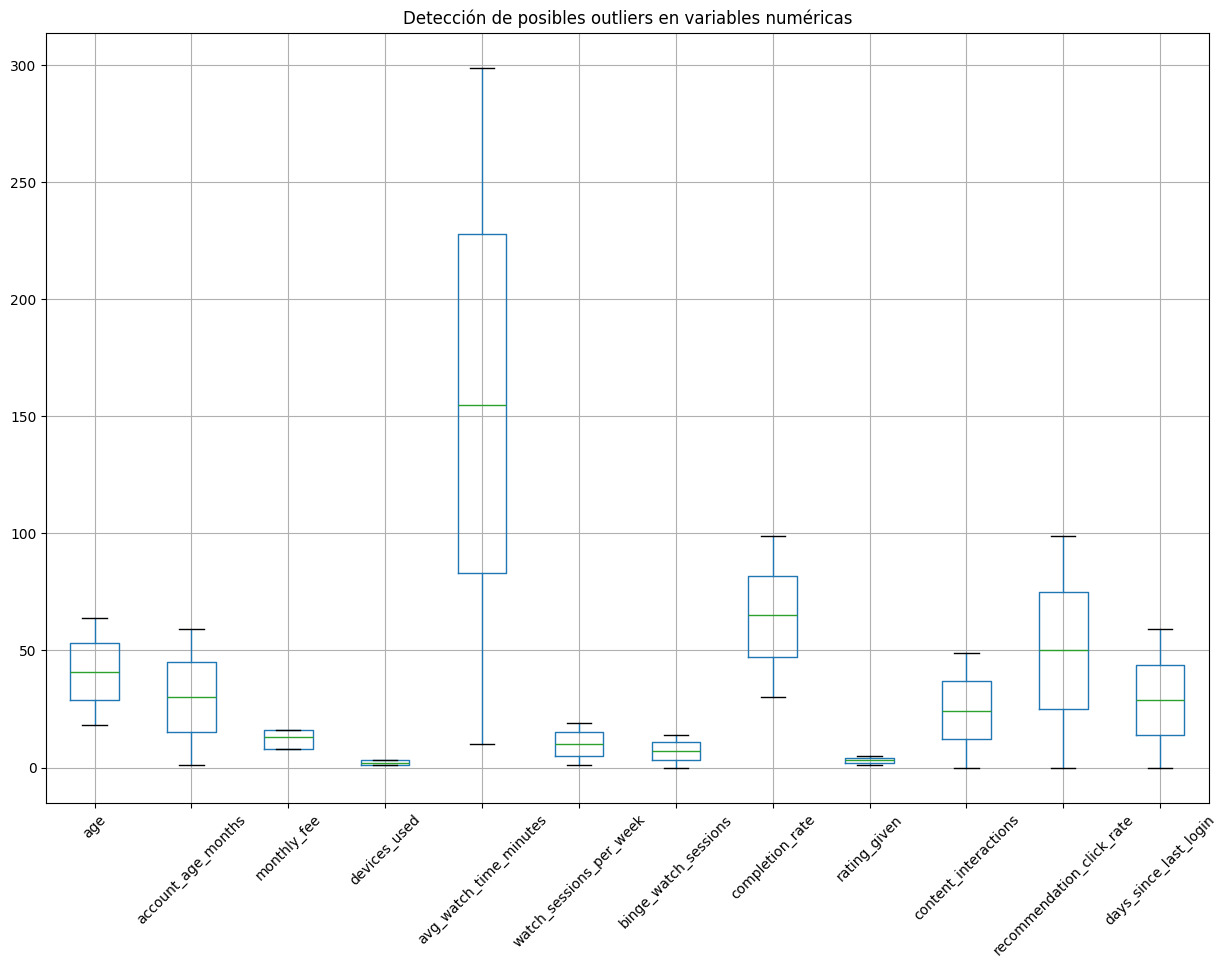

In [27]:
# Visualizar posibles outliers
plt.figure(figsize=(15, 10))
df[columnas_numericas].boxplot(rot=45)
plt.title("Detección de posibles outliers en variables numéricas")
plt.show()

In [28]:
# Resumen estadístico de variables numéricas
df[columnas_numericas].describe()

,age,account_age_months,monthly_fee,devices_used,avg_watch_time_minutes,watch_sessions_per_week,binge_watch_sessions,completion_rate,rating_given,content_interactions,recommendation_click_rate,days_since_last_login
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,40.979240,29.874000,12.323340,1.999140,154.946520,9.986920,7.002520,64.533420,3.002316,24.306380,49.563000,29.410520
std,13.528733,17.051104,3.309109,0.818238,83.727292,5.480616,4.335819,20.206377,1.152308,14.468037,28.816997,17.312414
min,18.000000,1.000000,7.990000,1.000000,10.000000,1.000000,0.000000,30.000000,1.000000,0.000000,0.000000,0.000000
25%,29.000000,15.000000,7.990000,1.000000,83.000000,5.000000,3.000000,47.000000,2.000000,12.000000,25.000000,14.000000
50%,41.000000,30.000000,12.990000,2.000000,155.000000,10.000000,7.000000,65.000000,3.000000,24.000000,50.000000,29.000000
75%,53.000000,45.000000,15.990000,3.000000,228.000000,15.000000,11.000000,82.000000,4.000000,37.000000,75.000000,44.000000
max,64.000000,59.000000,15.990000,3.000000,299.000000,19.000000,14.000000,99.000000,5.000000,49.000000,99.000000,59.000000


In [31]:
# Crear copia del dataset limpio
df_limpio = df.copy()

print("Limpieza básica completada")

Limpieza básica completada


### Sobre la limpieza

Se revisaron valores nulos, duplicados y outliers en el dataset.
No se detectaron problemas graves de nulos o duplicados, pero igualmente se documentó su revisión como parte del flujo de limpieza

In [32]:
# Crear nueva columna de actividad del usuario
df_limpio["nivel_actividad"] = pd.cut(
    df_limpio["watch_sessions_per_week"],
    bins=[0, 6, 12, 20],
    labels=["Baja", "Media", "Alta"]
)

df_limpio[["watch_sessions_per_week", "nivel_actividad"]].head()

,watch_sessions_per_week,nivel_actividad
0,17,Alta
1,15,Alta
2,6,Baja
3,4,Baja
4,15,Alta


In [33]:
# Separar variables predictoras y variable objetivo
X = df_limpio.drop(columns=["churned"])
y = df_limpio["churned"]

print("Variables predictoras:", X.shape)
print("Variable objetivo:", y.shape)

Variables predictoras: (50000, 19)
Variable objetivo: (50000,)


In [34]:
# Identificar columnas numéricas y categóricas
columnas_numericas = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
columnas_categoricas = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Columnas numéricas:")
print(columnas_numericas)

print("\nColumnas categóricas:")
print(columnas_categoricas)

Columnas numéricas:
['age', 'account_age_months', 'monthly_fee', 'devices_used', 'avg_watch_time_minutes', 'watch_sessions_per_week', 'binge_watch_sessions', 'completion_rate', 'rating_given', 'content_interactions', 'recommendation_click_rate', 'days_since_last_login']

Columnas categóricas:
['gender', 'country', 'subscription_type', 'payment_method', 'primary_device', 'favorite_genre', 'nivel_actividad']


In [35]:
# Crear transformador de columnas
preprocesador = ColumnTransformer(transformers=[
    ("num", StandardScaler(), columnas_numericas),
    ("cat", OneHotEncoder(handle_unknown="ignore"), columnas_categoricas)
])

print("Preprocesador creado correctamente")

Preprocesador creado correctamente


In [36]:
# Crear pipeline de preprocesamiento
pipeline_final = Pipeline(steps=[
    ("prep", preprocesador)
])

print("Pipeline creado correctamente")

Pipeline creado correctamente


In [37]:
# Aplicar transformación
X_transformado = pipeline_final.fit_transform(X)

print("Transformación completada")
print("Dimensión de la matriz transformada:", X_transformado.shape)

Transformación completada
Dimensión de la matriz transformada: (50000, 47)


## 6. Visualización final

En esta sección se presenta una visualización que resume una relación importante en el dataset.
Se analizará la relación entre el nivel de actividad del usuario y la variable churned, con el fin de observar si los usuarios menos activos presentan una mayor tendencia al abandono.

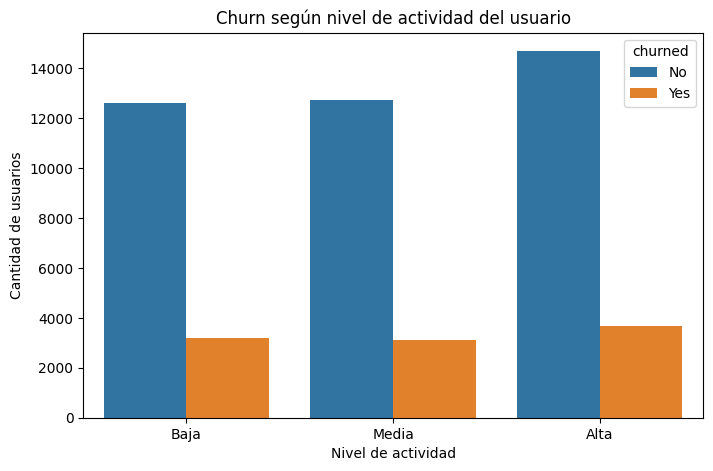

In [38]:
# Gráfico de churn por nivel de actividad
plt.figure(figsize=(8, 5))
sns.countplot(data=df_limpio, x="nivel_actividad", hue="churned")
plt.title("Churn según nivel de actividad del usuario")
plt.xlabel("Nivel de actividad")
plt.ylabel("Cantidad de usuarios")
plt.show()

## 7. Conclusiones

En este proyecto se realizó la exploración, limpieza y transformación de un dataset de usuarios de Netflix.

Se revisaron nulos, duplicados y outliers, además de eliminar la columna user_id por no aportar al análisis.

Luego, se creó la variable nivel_activida y se aplicaron técnicas como StandardScaler, OneHotEncoder y Pipeline para preparar los datos de forma ordenada y reproducible.

In [39]:
# Guardar dataset procesado
df_limpio.to_csv("netflix_limpio_transformado.csv", index=False)

print("Dataset procesado guardado correctamente")

Dataset procesado guardado correctamente


## 8. Continuación Evaluación Parcial 2: Modelado predictivo

En la evaluación anterior se realizó la exploración, limpieza y transformación inicial del dataset.  
En esta segunda parte se continúa con el mismo proyecto, usando el dataset ya preparado para implementar modelos de machine learning.

El objetivo de esta etapa es aplicar modelos supervisados y no supervisados, comparar métricas, optimizar hiperparámetros y analizar qué modelo funciona mejor para predecir el abandono de usuarios, es decir, la variable churned.

In [50]:
# Importamos librerías necesarias
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
print("Librerías para modelado cargadas correctamente")

Librerías para modelado cargadas correctamente


## 9. Preparación de datos para modelos supervisados

Primero se separan las variables predictoras de la variable objetivo.  
La variable objetivo es churned, porque indica si el usuario abandonó o no la plataforma.

También se usa train_test_split para separar los datos en entrenamiento y prueba. Esto permite entrenar los modelos con una parte de los datos y luego evaluarlos con datos que el modelo no ha visto antes.

In [52]:
# Verificar que exista el dataset limpio creado en la etapa anterior
print("Columnas disponibles en df_limpio:")
print(df_limpio.columns.tolist())

# Separar variables predictoras y variable objetivo
X = df_limpio.drop(columns=["churned"])
y = df_limpio["churned"]

# Convertir la variable objetivo a formato numérico
# No = 0, Yes = 1
y = y.map({"No": 0, "Yes": 1})

# Identificar columnas numéricas y categóricas
columnas_numericas = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
columnas_categoricas = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Columnas numéricas:")
print(columnas_numericas)

print("\nColumnas categóricas:")
print(columnas_categoricas)

print("\nDistribución de la variable churned:")
print(y.value_counts())

Columnas disponibles en df_limpio:
['age', 'gender', 'country', 'account_age_months', 'subscription_type', 'monthly_fee', 'payment_method', 'primary_device', 'devices_used', 'favorite_genre', 'avg_watch_time_minutes', 'watch_sessions_per_week', 'binge_watch_sessions', 'completion_rate', 'rating_given', 'content_interactions', 'recommendation_click_rate', 'days_since_last_login', 'churned', 'nivel_actividad']
Columnas numéricas:
['age', 'account_age_months', 'monthly_fee', 'devices_used', 'avg_watch_time_minutes', 'watch_sessions_per_week', 'binge_watch_sessions', 'completion_rate', 'rating_given', 'content_interactions', 'recommendation_click_rate', 'days_since_last_login']

Columnas categóricas:
['gender', 'country', 'subscription_type', 'payment_method', 'primary_device', 'favorite_genre', 'nivel_actividad']

Distribución de la variable churned:
churned
0    40036
1     9964
Name: count, dtype: int64


In [42]:
# Separar datos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Tamaño de X_train:", X_train.shape)
print("Tamaño de X_test:", X_test.shape)
print("Tamaño de y_train:", y_train.shape)
print("Tamaño de y_test:", y_test.shape)

Tamaño de X_train: (40000, 19)
Tamaño de X_test: (10000, 19)
Tamaño de y_train: (40000,)
Tamaño de y_test: (10000,)


In [43]:
# Crear preprocesador para modelos
# Las variables numéricas se escalan y las categóricas se transforman con OneHotEncoder
preprocesador_modelos = ColumnTransformer(transformers=[
    ("num", StandardScaler(), columnas_numericas),
    ("cat", OneHotEncoder(handle_unknown="ignore"), columnas_categoricas)
])

print("Preprocesador para modelos creado correctamente")

Preprocesador para modelos creado correctamente


## 10. Modelos supervisados de clasificación

Como el objetivo principal es predecir si un usuario abandona o no la plataforma, se aplican modelos de clasificación.

Se comparan tres modelos:

- Regresión Logística.
- Árbol de Decisión.
- Random Forest.

Estos modelos permiten estimar la clase final del usuario: abandona (Yes) o no abandona (No).

In [44]:
# Definir modelos de clasificación con pipeline
modelos_clasificacion = {
    "Regresión Logística": Pipeline(steps=[
        ("preprocesador", preprocesador_modelos),
        ("modelo", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
    ]),
    "Árbol de Decisión": Pipeline(steps=[
        ("preprocesador", preprocesador_modelos),
        ("modelo", DecisionTreeClassifier(random_state=RANDOM_STATE))
    ]),
    "Random Forest": Pipeline(steps=[
        ("preprocesador", preprocesador_modelos),
        ("modelo", RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1))
    ])
}

print("Modelos de clasificación definidos correctamente")

Modelos de clasificación definidos correctamente


In [45]:
# Entrenar y evaluar modelos de clasificación
resultados_clasificacion = []

for nombre, modelo in modelos_clasificacion.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    if hasattr(modelo.named_steps["modelo"], "predict_proba"):
        y_proba = modelo.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_proba)
    else:
        roc_auc = np.nan

    resultados_clasificacion.append({
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc
    })

resultados_clasificacion_df = pd.DataFrame(resultados_clasificacion)
resultados_clasificacion_df

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Regresión Logística,0.8007,0.000000,0.000000,0.000000,0.491286
1,Árbol de Decisión,0.6620,0.195967,0.224285,0.209172,0.497618
2,Random Forest,0.8007,0.000000,0.000000,0.000000,0.500804


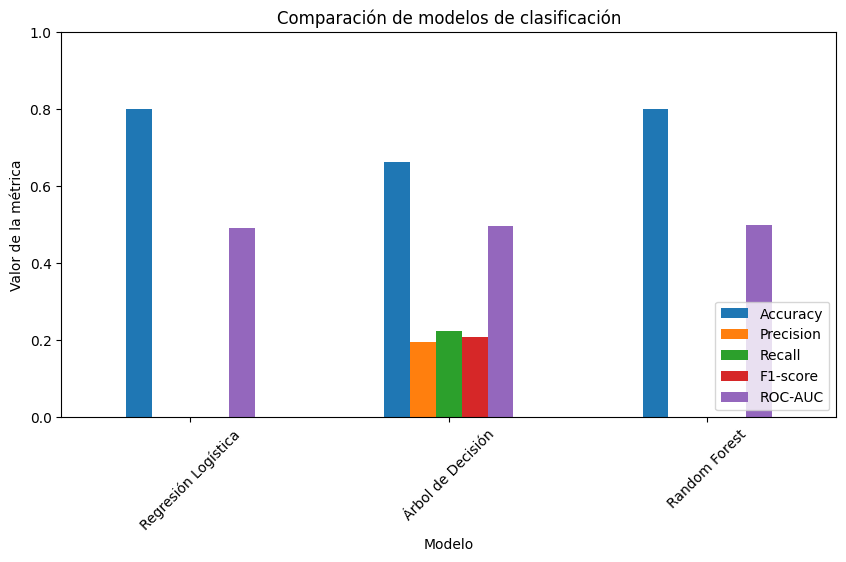

In [46]:
# Visualizar comparación de métricas de clasificación
resultados_clasificacion_df.set_index("Modelo")[["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]].plot(kind="bar", figsize=(10, 5))
plt.title("Comparación de modelos de clasificación")
plt.ylabel("Valor de la métrica")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.show()

### Interpretación de los modelos de clasificación

La comparación permite observar qué modelo tiene mejor rendimiento para identificar usuarios que abandonan la plataforma.  
En este problema no basta con mirar solo `accuracy`, porque si hay más usuarios que no abandonan, un modelo podría acertar mucho solo prediciendo la clase mayoritaria.

Por eso también se revisan:

- `precision`: qué tan confiables son las predicciones de abandono.
- `recall`: cuántos abandonos reales logra detectar el modelo.
- `F1-score`: equilibrio entre precision y recall.
- `ROC-AUC`: capacidad general del modelo para separar usuarios que abandonan y usuarios que no abandonan.

Mejor modelo según F1-score: Árbol de Decisión


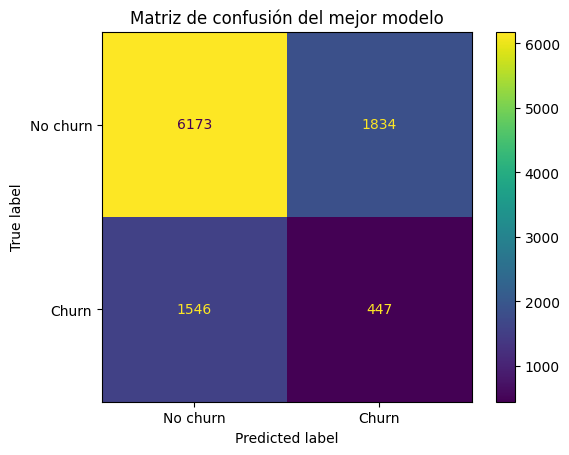

              precision    recall  f1-score   support

    No churn       0.80      0.77      0.79      8007
       Churn       0.20      0.22      0.21      1993

    accuracy                           0.66     10000
   macro avg       0.50      0.50      0.50     10000
weighted avg       0.68      0.66      0.67     10000



In [47]:
# Seleccionar el mejor modelo según F1-score
mejor_modelo_nombre = resultados_clasificacion_df.sort_values(by="F1-score", ascending=False).iloc[0]["Modelo"]
mejor_modelo = modelos_clasificacion[mejor_modelo_nombre]

print("Mejor modelo según F1-score:", mejor_modelo_nombre)

# Matriz de confusión del mejor modelo
y_pred_mejor = mejor_modelo.predict(X_test)
matriz = confusion_matrix(y_test, y_pred_mejor)

ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=["No churn", "Churn"]).plot()
plt.title("Matriz de confusión del mejor modelo")
plt.show()

print(classification_report(y_test, y_pred_mejor, target_names=["No churn", "Churn"]))

## 11. Validación cruzada

La validación cruzada permite evaluar los modelos de forma más estable.  
En vez de depender de una sola división entre entrenamiento y prueba, se realizan varias divisiones internas y se calcula el rendimiento promedio.

En este caso se usa `StratifiedKFold`, porque mantiene proporciones similares entre usuarios que abandonan y no abandonan en cada partición.

In [48]:
# Validación cruzada para modelos de clasificación
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
metricas_cv = ["accuracy", "precision", "recall", "f1", "roc_auc"]

resultados_cv = []

for nombre, modelo in modelos_clasificacion.items():
    scores = cross_validate(modelo, X, y, cv=cv, scoring=metricas_cv, n_jobs=-1)
    resultados_cv.append({
        "Modelo": nombre,
        "Accuracy promedio": scores["test_accuracy"].mean(),
        "Precision promedio": scores["test_precision"].mean(),
        "Recall promedio": scores["test_recall"].mean(),
        "F1-score promedio": scores["test_f1"].mean(),
        "ROC-AUC promedio": scores["test_roc_auc"].mean()
    })

resultados_cv_df = pd.DataFrame(resultados_cv)
resultados_cv_df

,Modelo,Accuracy promedio,Precision promedio,Recall promedio,F1-score promedio,ROC-AUC promedio
0,Regresión Logística,0.80072,0.000000,0.000000,0.000000,0.501072
1,Árbol de Decisión,0.66104,0.191086,0.216478,0.202935,0.494079
2,Random Forest,0.80072,0.000000,0.000000,0.000000,0.502730


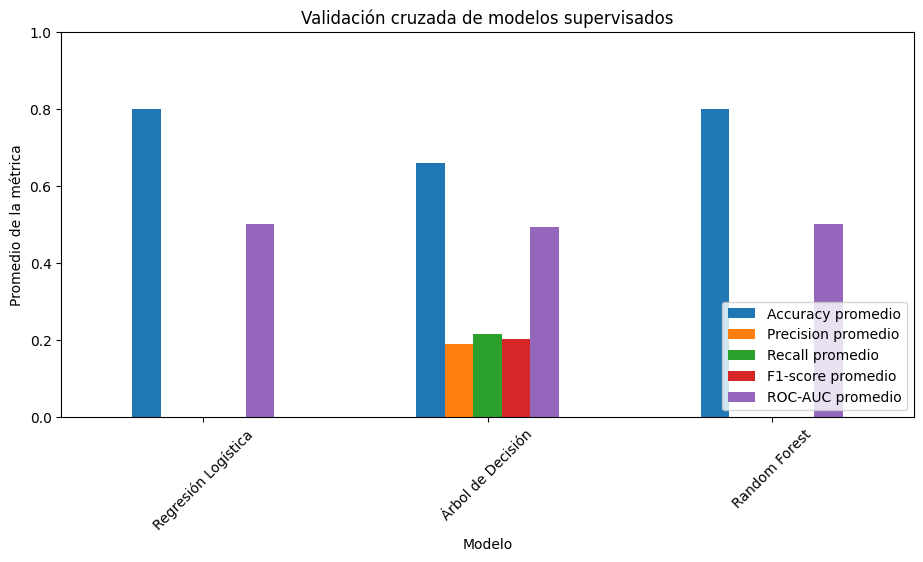

In [49]:
# Gráfico de resultados de validación cruzada
resultados_cv_df.set_index("Modelo").plot(kind="bar", figsize=(11, 5))
plt.title("Validación cruzada de modelos supervisados")
plt.ylabel("Promedio de la métrica")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.show()

## 12. Modelo supervisado de regresión

Aunque el problema principal es de clasificación, también se incluye una regresión para cumplir con la aplicación de modelos supervisados de distinto tipo.

En este caso se intenta predecir `avg_watch_time_minutes`, que corresponde al tiempo promedio de visualización.  
Para esto se usan variables del comportamiento del usuario, pero se elimina la misma variable objetivo desde las predictoras para evitar fuga de información.

In [ ]:
# Preparar datos para regresión
objetivo_regresion = "avg_watch_time_minutes"

X_reg = df_limpio.drop(columns=[objetivo_regresion])
y_reg = df_limpio[objetivo_regresion]

# Si churned está como texto, se mantiene como categórica para OneHotEncoder
columnas_numericas_reg = X_reg.select_dtypes(include=["int64", "float64"]).columns.tolist()
columnas_categoricas_reg = X_reg.select_dtypes(include=["object", "category"]).columns.tolist()

preprocesador_regresion = ColumnTransformer(transformers=[
    ("num", StandardScaler(), columnas_numericas_reg),
    ("cat", OneHotEncoder(handle_unknown="ignore"), columnas_categoricas_reg)
])

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print("Datos de regresión preparados correctamente")

In [ ]:
# Definir modelos de regresión
modelos_regresion = {
    "Regresión Lineal": Pipeline(steps=[
        ("preprocesador", preprocesador_regresion),
        ("modelo", LinearRegression())
    ]),
    "Random Forest Regressor": Pipeline(steps=[
        ("preprocesador", preprocesador_regresion),
        ("modelo", RandomForestRegressor(n_estimators=80, random_state=RANDOM_STATE, n_jobs=-1))
    ])
}

resultados_regresion = []

for nombre, modelo in modelos_regresion.items():
    modelo.fit(X_train_reg, y_train_reg)
    y_pred_reg = modelo.predict(X_test_reg)

    resultados_regresion.append({
        "Modelo": nombre,
        "MAE": mean_absolute_error(y_test_reg, y_pred_reg),
        "RMSE": np.sqrt(mean_squared_error(y_test_reg, y_pred_reg)),
        "R2": r2_score(y_test_reg, y_pred_reg)
    })

resultados_regresion_df = pd.DataFrame(resultados_regresion)
resultados_regresion_df

In [ ]:
# Visualizar comparación de R2 en regresión
plt.figure(figsize=(7, 4))
sns.barplot(data=resultados_regresion_df, x="Modelo", y="R2")
plt.title("Comparación de modelos de regresión según R2")
plt.ylabel("R2")
plt.xlabel("Modelo")
plt.xticks(rotation=20)
plt.show()

## 13. Aprendizaje no supervisado: clustering

El aprendizaje no supervisado se utiliza para encontrar grupos de usuarios sin usar la variable `churned` como respuesta.

En esta parte se aplica `KMeans`, que agrupa usuarios según similitudes en sus variables de comportamiento.  
Luego se evalúa la calidad de los grupos usando métricas como `silhouette_score`, `Davies-Bouldin` y `Calinski-Harabasz`.

In [53]:
# Preparar datos para aprendizaje no supervisado
# Se elimina churned porque en clustering no se usa la etiqueta real
X_cluster = df_limpio.drop(columns=["churned"])

columnas_numericas_cluster = X_cluster.select_dtypes(include=["int64", "float64"]).columns.tolist()
columnas_categoricas_cluster = X_cluster.select_dtypes(include=["object", "category"]).columns.tolist()

preprocesador_cluster = ColumnTransformer(transformers=[
    ("num", StandardScaler(), columnas_numericas_cluster),
    ("cat", OneHotEncoder(handle_unknown="ignore"), columnas_categoricas_cluster)
])

X_cluster_transformado = preprocesador_cluster.fit_transform(X_cluster)

print("Datos preparados para clustering")
print("Dimensión de los datos transformados:", X_cluster_transformado.shape)

Datos preparados para clustering
Dimensión de los datos transformados: (50000, 47)


In [54]:
# Evaluar distintos números de clusters
resultados_cluster = []

for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    etiquetas = kmeans.fit_predict(X_cluster_transformado)

    resultados_cluster.append({
        "k": k,
        "Inercia": kmeans.inertia_,
        "Silhouette": silhouette_score(X_cluster_transformado, etiquetas),
        "Davies-Bouldin": davies_bouldin_score(X_cluster_transformado.toarray() if hasattr(X_cluster_transformado, "toarray") else X_cluster_transformado, etiquetas),
        "Calinski-Harabasz": calinski_harabasz_score(X_cluster_transformado.toarray() if hasattr(X_cluster_transformado, "toarray") else X_cluster_transformado, etiquetas)
    })

resultados_cluster_df = pd.DataFrame(resultados_cluster)
resultados_cluster_df

,k,Inercia,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,2,810994.172626,0.061130,3.766164,3227.228491
1,3,784983.648896,0.051432,3.856917,2495.376377
2,4,768630.736942,0.043898,4.034214,2053.509596
3,5,751946.635469,0.043551,4.066772,1851.601050
4,6,743160.222680,0.036570,4.092500,1616.973070


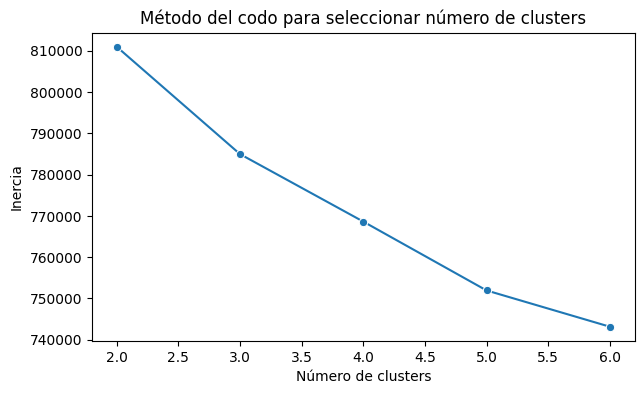

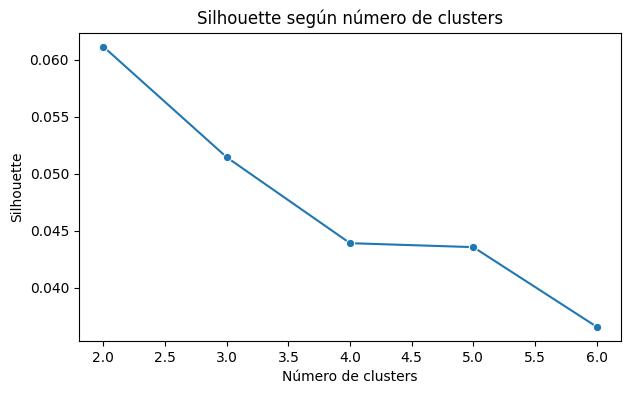

In [55]:
# Gráfico del método del codo
plt.figure(figsize=(7, 4))
sns.lineplot(data=resultados_cluster_df, x="k", y="Inercia", marker="o")
plt.title("Método del codo para seleccionar número de clusters")
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.show()

# Gráfico de Silhouette
plt.figure(figsize=(7, 4))
sns.lineplot(data=resultados_cluster_df, x="k", y="Silhouette", marker="o")
plt.title("Silhouette según número de clusters")
plt.xlabel("Número de clusters")
plt.ylabel("Silhouette")
plt.show()

In [ ]:
# Seleccionar el mejor k según Silhouette
mejor_k = resultados_cluster_df.sort_values(by="Silhouette", ascending=False).iloc[0]["k"]
mejor_k = int(mejor_k)

kmeans_final = KMeans(n_clusters=mejor_k, random_state=RANDOM_STATE, n_init=10)
df_limpio["cluster_usuario"] = kmeans_final.fit_predict(X_cluster_transformado)

print("Mejor número de clusters según Silhouette:", mejor_k)
print(df_limpio["cluster_usuario"].value_counts())

## 14. Reducción de dimensionalidad con PCA

PCA permite reducir muchas variables transformadas a dos componentes principales para visualizar los datos en un plano.  
Esto ayuda a observar si los clusters forman grupos separados o si los usuarios tienen comportamientos mezclados.

In [ ]:
# Convertir matriz a formato denso si es necesario
if hasattr(X_cluster_transformado, "toarray"):
    X_cluster_denso = X_cluster_transformado.toarray()
else:
    X_cluster_denso = X_cluster_transformado

# Aplicar PCA a dos componentes
pca = PCA(n_components=2, random_state=RANDOM_STATE)
componentes = pca.fit_transform(X_cluster_denso)

pca_df = pd.DataFrame(componentes, columns=["PC1", "PC2"])
pca_df["cluster_usuario"] = df_limpio["cluster_usuario"].values
pca_df["churned"] = df_limpio["churned"].values

print("Varianza explicada por cada componente:")
print(pca.explained_variance_ratio_)

In [ ]:
# Visualización de clusters con PCA
plt.figure(figsize=(8, 5))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="cluster_usuario", palette="viridis", alpha=0.6)
plt.title("Visualización de clusters usando PCA")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.show()

In [ ]:
# Relación entre clusters y churned
plt.figure(figsize=(8, 5))
sns.countplot(data=df_limpio, x="cluster_usuario", hue="churned")
plt.title("Distribución de churned por cluster de usuario")
plt.xlabel("Cluster")
plt.ylabel("Cantidad de usuarios")
plt.show()

pd.crosstab(df_limpio["cluster_usuario"], df_limpio["churned"], normalize="index")

## 15. Optimización de hiperparámetros con GridSearchCV

La optimización de hiperparámetros permite buscar configuraciones que mejoren el rendimiento del modelo.  
Primero se utiliza `GridSearchCV`, que prueba combinaciones específicas definidas manualmente.

En este caso se optimiza un Random Forest porque es un modelo robusto para clasificación y permite capturar relaciones no lineales entre variables.

In [ ]:
# Pipeline base para Random Forest
pipeline_rf = Pipeline(steps=[
    ("preprocesador", preprocesador_modelos),
    ("modelo", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
])

# Parámetros para GridSearchCV
parametros_grid = {
    "modelo__n_estimators": [50, 100],
    "modelo__max_depth": [None, 10, 20],
    "modelo__min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=parametros_grid,
    scoring="f1",
    cv=3,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Mejores hiperparámetros con GridSearchCV:")
print(grid_search.best_params_)
print("Mejor F1-score en validación:", grid_search.best_score_)

In [ ]:
# Evaluar modelo optimizado con GridSearchCV
mejor_grid = grid_search.best_estimator_
y_pred_grid = mejor_grid.predict(X_test)
y_proba_grid = mejor_grid.predict_proba(X_test)[:, 1]

resultados_grid = {
    "Modelo": "Random Forest GridSearchCV",
    "Accuracy": accuracy_score(y_test, y_pred_grid),
    "Precision": precision_score(y_test, y_pred_grid, zero_division=0),
    "Recall": recall_score(y_test, y_pred_grid, zero_division=0),
    "F1-score": f1_score(y_test, y_pred_grid, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_proba_grid)
}

pd.DataFrame([resultados_grid])

## 16. Optimización de hiperparámetros con RandomizedSearchCV

También se aplica `RandomizedSearchCV`, que prueba combinaciones aleatorias dentro de un espacio de búsqueda.  
Esta técnica puede ser más eficiente cuando existen muchas combinaciones posibles.

In [ ]:
# Parámetros para RandomizedSearchCV
parametros_random = {
    "modelo__n_estimators": [50, 100, 150, 200],
    "modelo__max_depth": [None, 5, 10, 20, 30],
    "modelo__min_samples_split": [2, 5, 10],
    "modelo__min_samples_leaf": [1, 2, 4]
}

random_search = RandomizedSearchCV(
    estimator=pipeline_rf,
    param_distributions=parametros_random,
    n_iter=10,
    scoring="f1",
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Mejores hiperparámetros con RandomizedSearchCV:")
print(random_search.best_params_)
print("Mejor F1-score en validación:", random_search.best_score_)

In [ ]:
# Evaluar modelo optimizado con RandomizedSearchCV
mejor_random = random_search.best_estimator_
y_pred_random = mejor_random.predict(X_test)
y_proba_random = mejor_random.predict_proba(X_test)[:, 1]

resultados_random = {
    "Modelo": "Random Forest RandomizedSearchCV",
    "Accuracy": accuracy_score(y_test, y_pred_random),
    "Precision": precision_score(y_test, y_pred_random, zero_division=0),
    "Recall": recall_score(y_test, y_pred_random, zero_division=0),
    "F1-score": f1_score(y_test, y_pred_random, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_proba_random)
}

pd.DataFrame([resultados_random])

## 17. Comparación final de modelos

En esta sección se juntan los resultados de los modelos iniciales y los modelos optimizados.  
Esto permite analizar si la optimización de hiperparámetros mejoró o no el rendimiento final.

In [ ]:
# Unir resultados iniciales con resultados optimizados
comparacion_final = pd.concat([
    resultados_clasificacion_df,
    pd.DataFrame([resultados_grid]),
    pd.DataFrame([resultados_random])
], ignore_index=True)

comparacion_final

In [ ]:
# Gráfico de comparación final
comparacion_final.set_index("Modelo")[["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]].plot(kind="bar", figsize=(12, 6))
plt.title("Comparación final de modelos de clasificación")
plt.ylabel("Valor de la métrica")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.show()

In [ ]:
# Seleccionar modelo final según F1-score
modelo_final_nombre = comparacion_final.sort_values(by="F1-score", ascending=False).iloc[0]["Modelo"]

print("Modelo final seleccionado:", modelo_final_nombre)
print("\nTabla final ordenada por F1-score:")
comparacion_final.sort_values(by="F1-score", ascending=False)

### Interpretación final

El modelo final se selecciona principalmente usando `F1-score`, porque este indicador equilibra la capacidad del modelo para detectar abandonos reales y la precisión de sus predicciones.

Para un problema de churn, detectar correctamente a los usuarios que podrían abandonar es importante porque permite tomar acciones preventivas antes de que cancelen la suscripción.

La optimización con `GridSearchCV` y `RandomizedSearchCV` permite revisar si el modelo mejora al modificar hiperparámetros como la cantidad de árboles, la profundidad máxima y el número mínimo de muestras para dividir nodos.

## 18. Guardado de resultados

Finalmente, se guardan las tablas de métricas y el dataset con clusters.  
Esto permite dejar evidencia de los resultados obtenidos y facilita la reproducibilidad del proyecto.

In [ ]:
# Guardar resultados generados en esta segunda etapa
resultados_clasificacion_df.to_csv("resultados_clasificacion.csv", index=False)
resultados_cv_df.to_csv("resultados_validacion_cruzada.csv", index=False)
resultados_regresion_df.to_csv("resultados_regresion.csv", index=False)
resultados_cluster_df.to_csv("resultados_clustering.csv", index=False)
comparacion_final.to_csv("comparacion_final_modelos.csv", index=False)
df_limpio.to_csv("netflix_limpio_con_clusters.csv", index=False)

print("Archivos de resultados guardados correctamente")

## 19. Conclusiones de la Evaluación Parcial 2

En esta segunda parte del proyecto se continuó el trabajo anterior sobre el dataset de comportamiento de usuarios de Netflix.  
A partir del dataset limpio y transformado, se implementaron modelos supervisados de clasificación para predecir el abandono de usuarios.

También se aplicó un modelo de regresión para estimar el tiempo promedio de visualización y se incorporaron técnicas no supervisadas como KMeans y PCA para explorar grupos de usuarios según su comportamiento.

La comparación de métricas permitió evaluar los modelos usando `accuracy`, `precision`, `recall`, `F1-score` y `ROC-AUC`. Además, la optimización con `GridSearchCV` y `RandomizedSearchCV` permitió analizar si el ajuste de hiperparámetros mejora el rendimiento del modelo.

En términos generales, esta etapa completa el ciclo de machine learning solicitado en la evaluación, ya que incluye preparación de datos, entrenamiento, evaluación, comparación, optimización e interpretación de resultados.